<a href="https://colab.research.google.com/github/Lasdina/online-retail-II-end-to-end-analysis/blob/main/End_to_End_B2B_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Tahap: Data Preparation & Processing

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/002.BUILD PORTOFOLIO/online_retail_II.xlsx')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df['Customer ID'].isnull().sum()

np.int64(135080)

In [ ]:
# 1. Menghapus baris tanpa Customer ID
missing_customer = df['Customer ID'].isnull().sum()
df.dropna(subset=['Customer ID'], inplace=True)

In [ ]:
# 2. Menghapus baris dengan Harga (Price) <= 0
# Justifikasi: Harga nol atau negatif biasanya merupakan data error, promosi, atau penyesuaian stok yang bukan penjualan riil.
df = df[df['Price'] > 0]

In [ ]:
import re

# 1. Pastikan StockCode bertipe string dan bersih dari spasi
df['StockCode'] = df['StockCode'].astype(str).str.strip()

# 2. Definisikan Fungsi untuk Cek Produk Fisik
def is_physical_product(code):
    # Pola: Mencari 5 digit angka di awal (seperti 85123 atau 85123A)
    pattern = r'^\d{5}'
    if re.match(pattern, code):
        return True
    return False

# 3. Terapkan Masking
# Kita hanya menyimpan yang sesuai pola produk fisik
df_cleaned = df[df['StockCode'].apply(is_physical_product)].copy()

# Cek hasil: Apa saja yang terhapus?
dropped_codes = df[~df['StockCode'].apply(is_physical_product)]['StockCode'].unique()
print(f"StockCode yang dihapus: {dropped_codes}")

StockCode yang dihapus: ['POST' 'D' 'C2' 'M' 'BANK CHARGES' 'PADS' 'DOT' 'CRUK']


💡 Penjelasan Portofolio:

Kenapa menghapus Missing Customer ID? Karena tujuan proyek kita adalah Segmentasi Pelanggan (RFM). Tanpa ID, kita tidak bisa melacak histori belanja per individu/toko, sehingga data tersebut tidak relevan untuk analisis ini.

#cek duplicated

In [ ]:
df_cleaned.duplicated().sum()

np.int64(5220)

In [ ]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df_cleaned.duplicated().sum()

np.int64(0)

In [ ]:
df_cleaned.shape

(399656, 8)

#Handling cancels

In [ ]:
# Membuat kolom baru untuk menandai status transaksi
df_cleaned['Is_Cancelled'] = df['Invoice'].astype(str).str.startswith('C')
df_cleaned.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Is_Cancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False


In [ ]:
# Memisahkan DataFrame untuk analisis mendalam nanti
df_normal = df_cleaned[df_cleaned['Is_Cancelled'] == False].copy()
df_cancelled = df_cleaned[df_cleaned['Is_Cancelled'] == True].copy()
df_cleaned.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Is_Cancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False


In [ ]:
df_cancelled.shape

(8506, 9)

In [ ]:
df_normal.shape

(391150, 9)

In [ ]:
# Tambahkan .round(2) untuk membatasi 2 angka di belakang koma
df_normal['Total_Amount'] = (df_normal['Quantity'] * df_normal['Price']).round(2)

In [ ]:
# Feature Engineering: Menghitung Total Penjualan per baris
df_normal['Total_Amount'] = df_normal['Quantity'] * df_normal['Price']

In [ ]:
print(f"Transaksi Sukses: {df_normal.shape[0]} baris")
print(f"Transaksi Batal (C): {df_cancelled.shape[0]} baris")

Transaksi Sukses: 391150 baris
Transaksi Batal (C): 8506 baris


In [ ]:
df_normal.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Is_Cancelled,Total_Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34


In [ ]:
df_normal.to_csv('data_clear.csv')

#Modeling (SQL)

Step 4: Transformasi ke Skema Relasional (Modeling)
Inilah inti dari judul "Transforming Flat-File into Relational Insights". Kita pecah tabel besar menjadi tabel-tabel kecil yang saling berhubungan.

In [ ]:
# 1. Dim_Customer (Tabel Pelanggan)
dim_customer = df_normal[['Customer ID', 'Country']].drop_duplicates(subset=['Customer ID'])

# 2. Dim_Product (Tabel Produk)
# Kita ambil deskripsi terbaru untuk setiap StockCode
dim_product = df_normal[['StockCode', 'Description', 'Price']].drop_duplicates(subset=['StockCode'])
dim_product.rename(columns={'Price': 'Unit_Price'}, inplace=True)

# 3. Fact_Sales (Tabel Fakta Transaksi)
fact_sales = df_normal[['Invoice', 'Customer ID', 'StockCode', 'Quantity', 'Total_Amount', 'InvoiceDate']]

print("Transformasi Skema Relasional Berhasil!")

Transformasi Skema Relasional Berhasil!


In [ ]:
dim_customer.shape

(4334, 2)

In [ ]:
dim_product.shape

(3659, 3)

In [ ]:
fact_sales.shape

(391150, 6)

#Ekspor data visualisasi di tableau
Step 5: Optimasi RAM & Ekspor Data
Langkah terakhir untuk memastikan file ringan saat ditarik ke Looker Studio atau Tableau.

In [ ]:
# Ubah tipe data tetap sama
fact_sales['Customer ID'] = fact_sales['Customer ID'].astype(int)
dim_customer['Customer ID'] = dim_customer['Customer ID'].astype(int)

# --- BAGIAN YANG DIEDIT: Menambahkan sep=',' ---

# Ekspor Fact Sales
fact_sales.to_csv('fact_sales_clean.csv', index=False, sep=',', encoding='utf-8')

# Ekspor Dim Customer
dim_customer.to_csv('dim_customer.csv', index=False, sep=',', encoding='utf-8')

# Ekspor Dim Product
dim_product.to_csv('dim_product.csv', index=False, sep=',', encoding='utf-8')

# Ekspor Fact Cancellations (Retur)
df_cancelled.to_csv('fact_cancellations.csv', index=False, sep=',', encoding='utf-8')

print("Semua file telah siap! Silakan download ulang dan masukkan ke Tableau.")

/tmp/ipykernel_2375/2250043800.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_sales['Customer ID'] = fact_sales['Customer ID'].astype(int)


Semua file telah siap! Silakan download ulang dan masukkan ke Tableau.


In [ ]:
# Mengubah tipe data agar lebih hemat memori (Optimasi Celeron)
fact_sales['Customer ID'] = fact_sales['Customer ID'].astype(int)
dim_customer['Customer ID'] = dim_customer['Customer ID'].astype(int)

# Ekspor ke CSV (Lebih ringan dari Excel)
fact_sales.to_csv('fact_sales_clean.xlsx', index=False)
dim_customer.to_csv('dim_customer.xlsx', index=False)
dim_product.to_csv('dim_product.xlsx', index=False)
df_cancelled.to_csv('fact_cancellations.xlsx', index=False)

print("Semua file telah siap untuk tahap EDA dan Visualisasi!")

/tmp/ipykernel_3569/3290862588.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_sales['Customer ID'] = fact_sales['Customer ID'].astype(int)


Semua file telah siap untuk tahap EDA dan Visualisasi!


In [ ]:
# Mengubah tipe data agar lebih hemat memori (Optimasi Celeron)
fact_sales['Customer ID'] = fact_sales['Customer ID'].astype(int)
dim_customer['Customer ID'] = dim_customer['Customer ID'].astype(int)

# Ekspor ke CSV (Lebih ringan dari Excel)
fact_sales.to_csv('fact_sales_clean.csv', index=False)
dim_customer.to_csv('dim_customer.csv', index=False)
dim_product.to_csv('dim_product.csv', index=False)
df_cancelled.to_csv('fact_cancellations.csv', index=False)

print("Semua file telah siap untuk tahap EDA dan Visualisasi!")

/tmp/ipykernel_4340/1002090121.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_sales['Customer ID'] = fact_sales['Customer ID'].astype(int)


Semua file telah siap untuk tahap EDA dan Visualisasi!


Apa yang Terjadi di Balik Layar?
Dengan menjalankan syntax di atas, kamu telah melakukan:

Integritas Data: Menghapus data sampah yang bisa mengacaukan hasil statistik.

Efisiensi Database: Dengan memecah menjadi dim dan fact, kamu meniru cara kerja Data Warehouse profesional.

Kesiapan Analisis: Kamu punya file terpisah khusus untuk "Cancellations" yang bisa menjadi poin pembahasan menarik di bab Business Insights.

Langkah selanjutnya: Kita akan masuk ke tahap EDA (Exploratory Data Analysis) untuk mencari tren penjualan dan menghitung skor RFM. Apakah kamu ingin lanjut ke bagian perhitungan RFM dengan Python?

#Analisis RFM

📈 Tahap: EDA & RFM Segmentation
Step 1: Menghitung Metrik RFM
RFM adalah standar emas dalam analisis retail B2B untuk memahami nilai pelanggan.

Recency: Jumlah hari sejak transaksi terakhir (Semakin kecil semakin baik).

Frequency: Jumlah total transaksi (Semakin besar semakin setia).

Monetary: Total uang yang dihabiskan (Semakin besar semakin menguntungkan).

In [ ]:
# Menetapkan tanggal referensi (satu hari setelah tanggal transaksi terakhir di dataset)
snapshot_date = fact_sales['InvoiceDate'].max() + pd.Timedelta(days=1)

# Agregasi data berdasarkan Customer ID
rfm = fact_sales.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'Invoice': 'nunique',                                   # Frequency
    'Total_Amount': 'sum'                                   # Monetary
})

# Rename kolom agar lebih mudah dibaca
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'Total_Amount': 'Monetary'
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1437.24
12349,19,1,1457.55
12350,310,1,294.40


Penjelasan:

Recency: Jumlah hari sejak pesanan terakhir. Semakin kecil nilainya, semakin baik.

Frequency: Berapa kali mereka melakukan order unik.

Monetary: Total uang yang mereka belanjakan.

Alasan: Mengubah ribuan data transaksi menjadi profil perilaku pelanggan tunggal.

In [ ]:
rfm.shape

(4334, 3)

Step 2: Scoring (Pemberian Skor 1-5)
Kita akan membagi pelanggan ke dalam 5 kelompok (kuintil) untuk setiap metrik.

Catatan: Untuk Recency, skor 5 diberikan pada angka hari yang paling kecil (karena baru saja belanja adalah hal bagus).

In [ ]:
# Membuat label skor dari 1 sampai 5
r_labels = range(5, 0, -1) # 5 adalah yang paling baru (Recency rendah)
f_labels = range(1, 6)      # 5 adalah yang paling sering
m_labels = range(1, 6)      # 5 adalah yang paling banyak uangnya

# Menggunakan qcut untuk membagi data menjadi 5 bagian sama rata
rfm['R'] = pd.qcut(rfm['Recency'], q=5, labels=r_labels)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=f_labels)
rfm['M'] = pd.qcut(rfm['Monetary'], q=5, labels=m_labels)

# Menggabungkan skor menjadi satu kolom RFM_Group
rfm['RFM_Segment'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Segment
Customer ID,,,,,,,
12346,326,1,77183.60,1,1,5,115
12347,2,7,4310.00,5,5,5,555
12348,75,4,1437.24,2,4,4,244
12349,19,1,1457.55,4,1,4,414
12350,310,1,294.40,1,1,2,112


Step 3: Pengelompokan Segmen Bisnis (Naming)
Skor angka mungkin sulit dipahami oleh tim marketing, jadi kita beri nama yang manusiawi.

In [ ]:
def segment_me(df):
    if df['RFM_Segment'] == '555':
        return 'Champions'
    elif df['R'] == '5':
        return 'Recent Customers'
    elif df['F'] == '5':
        return 'Loyal Customers'
    elif df['M'] == '5':
        return 'Big Spenders'
    elif df['R'] == '1':
        return 'At Risk / Lost'
    else:
        return 'Average/Standard'

rfm['Customer_Status'] = rfm.apply(segment_me, axis=1)

# Melihat distribusi jumlah pelanggan per segmen
segment_counts = rfm['Customer_Status'].value_counts()
print(segment_counts)

Customer_Status
Average/Standard    3983
Champions            351
Name: count, dtype: int64


Step 4: Analisis Tren Penjualan Bulanan (EDA)
Untuk melihat performa distributor secara musiman.

/tmp/ipykernel_4340/1503272113.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_sales['Month_Year'] = fact_sales['InvoiceDate'].dt.to_period('M')


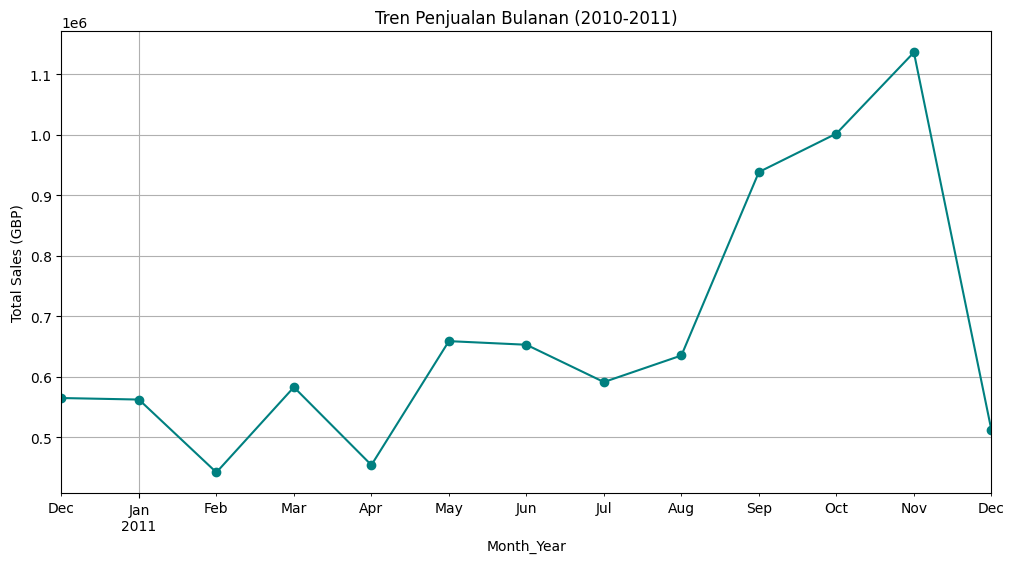

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menambah kolom bulan-tahun untuk analisis tren
fact_sales['Month_Year'] = fact_sales['InvoiceDate'].dt.to_period('M')
monthly_sales = fact_sales.groupby('Month_Year')['Total_Amount'].sum()

# Visualisasi
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line', marker='o', color='teal')
plt.title('Tren Penjualan Bulanan (2010-2011)')
plt.ylabel('Total Sales (GBP)')
plt.grid(True)
plt.show()

💡 Insight untuk Portofoliomu:
Interpretasi RFM: Jika kelompok "At Risk" memiliki jumlah yang besar, sarankan dalam rekomendasimu agar perusahaan mengirimkan email katalog baru atau diskon khusus "kami rindu Anda".

Tren Desember: Kamu akan melihat penurunan tajam di Desember 2011. Penting: Jelaskan di portofolio bahwa ini bukan performa buruk, melainkan data yang memang hanya sampai tanggal 9 Desember (data parsial). Ini menunjukkan ketelitianmu sebagai analis.

Net Sales vs Cancellation: Gunakan df_cancelled yang kita buat sebelumnya untuk menghitung berapa potensi kerugian dari retur barang.

Langkah Terakhir:
Setelah koding ini selesai, kamu bisa menyimpan file rfm.csv dan mengimpornya ke Looker Studio untuk membuat visualisasi dashboard yang cantik. Apakah kamu ingin saya bantu pandu cara menyusun visualisasi di Looker Studio agar terlihat profesional?

In [ ]:
rfm.to_csv('final_rfm_segmentation.csv')

In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 399656 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      399656 non-null  object        
 1   StockCode    399656 non-null  object        
 2   Description  399656 non-null  object        
 3   Quantity     399656 non-null  int64         
 4   InvoiceDate  399656 non-null  datetime64[ns]
 5   Price        399656 non-null  float64       
 6   Customer ID  399656 non-null  float64       
 7   Country      399656 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.4+ MB


In [ ]:
df.dropna()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
#handle missing value kolom customer id
# Cek apakah ada 1 Invoice yang punya lebih dari 1 Customer ID
check_consistency = data.groupby('Invoice')['Customer ID'].nunique()
print(f"Invoice dengan lebih dari 1 Customer ID: {(check_consistency > 1).sum()}")

Invoice dengan lebih dari 1 Customer ID: 0


In [ ]:
data['Description'].isnull().sum()

np.int64(1454)

Terdapat 135080 missing value. disini saya melakukan tahap cleaning bertahap. yaitu saya memulai cleaning dengan menghapus data secara langsung itu dihubungkan dengan kolom description yang kosong dan price yang bernilai 0 karena tujuan dari analisis ini ingin mendapat sales net yang bersih. sehingga keputusan menghapus data melalui price yang bernilai nol adalah tindakan yang sangat tepat karena data tersebut noise (sampah)

In [ ]:
# Menghapus baris yang harganya 0 atau Deskripsinya hilang
initial_count = len(data)
data = data.dropna(subset=['Description'])
data = data[data['Price'] > 0]

final_count = len(data)
print(f"Berhasil menghapus {initial_count - final_count} baris data tidak valid.")

Berhasil menghapus 2517 baris data tidak valid.


In [ ]:
data['Description'].isnull().sum()

np.int64(0)

In [ ]:
# 1. karena missing value masih ada maka akan dibuatkan customer id buatan
# 2. Tandai data agar analisis tetap jujur (Validasi untuk Portofolio)
data['Customer_Type'] = np.where(data['Customer ID'].isnull(), 'Unregistered', 'Registered')

# 3. Isi Customer ID yang kosong dengan identitas unik berdasarkan nomor Invoice
# Kita beri awalan 'GUEST_' agar jelas ini adalah pelanggan tanpa ID
data['Customer ID'] = data['Customer ID'].fillna('GUEST_' + data['Invoice'].astype(str))

In [ ]:
data['Customer ID'].isnull().sum()

np.int64(0)

In [ ]:
# 4. Hapus baris yang merupakan biaya jasa (bukan produk fisik)
service_codes = ['POST', 'D', 'DOT', 'M', 'BANK CHARGES', 'ADJ', 'S', 'AMAZONFEE']
data = data[~data['StockCode'].isin(service_codes)]

In [ ]:
import re

# 1. Pastikan StockCode bertipe string dan bersih dari spasi
data['StockCode'] = data['StockCode'].astype(str).str.strip()

# 2. Definisikan Fungsi untuk Cek Produk Fisik
def is_physical_product(code):
    # Pola: Mencari 5 digit angka di awal (seperti 85123 atau 85123A)
    pattern = r'^\d{5}'
    if re.match(pattern, code):
        return True
    return False

# 3. Terapkan Masking
# Kita hanya menyimpan yang sesuai pola produk fisik
data_cleaned = data[data['StockCode'].apply(is_physical_product)].copy()

# Cek hasil: Apa saja yang terhapus?
dropped_codes = data[~data['StockCode'].apply(is_physical_product)]['StockCode'].unique()
print(f"StockCode yang dihapus: {dropped_codes}")

StockCode yang dihapus: ['C2' 'DCGS0076' 'DCGS0003' 'gift_0001_40' 'DCGS0070' 'm' 'gift_0001_50'
 'gift_0001_30' 'gift_0001_20' 'DCGS0069' 'DCGSSBOY' 'DCGSSGIRL'
 'gift_0001_10' 'PADS' 'DCGS0004' 'B' 'CRUK']


#duplicate

In [ ]:
data_cleaned.duplicated().sum()

np.int64(5257)

In [ ]:
data_cleaned.drop_duplicates(inplace=True)
data_cleaned.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Customer_Type
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Registered
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Registered
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Registered
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Registered
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Registered


In [ ]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 531172 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Invoice        531172 non-null  object        
 1   StockCode      531172 non-null  object        
 2   Description    531172 non-null  object        
 3   Quantity       531172 non-null  int64         
 4   InvoiceDate    531172 non-null  datetime64[ns]
 5   Price          531172 non-null  float64       
 6   Customer ID    531172 non-null  object        
 7   Country        531172 non-null  object        
 8   Customer_Type  531172 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 40.5+ MB


#cancelss

In [ ]:
# Cek apakah ada Quantity negatif yang TIDAK memiliki awalan 'C'
anomali_1 = data_cleaned[(data_cleaned['Quantity'] < 0) & (~data_cleaned['Invoice'].astype(str).str.startswith('C'))]

# Cek apakah ada Invoice 'C' tapi Quantity-nya malah positif (jarang, tapi mungkin)
anomali_2 = data_cleaned[(data_cleaned['Invoice'].astype(str).str.startswith('C')) & (data_cleaned['Quantity'] > 0)]

print(f"Jumlah anomali Quantity negatif tanpa 'C': {len(anomali_1)}")
print(f"Jumlah anomali Invoice 'C' tapi Quantity positif: {len(anomali_2)}")

Jumlah anomali Quantity negatif tanpa 'C': 0
Jumlah anomali Invoice 'C' tapi Quantity positif: 0


In [ ]:
# Buat kolom baru untuk membedakan tipe transaksi
data_cleaned['Transaction_Status'] = 'Cancelled'
data_cleaned.loc[~data_cleaned['Invoice'].astype(str).str.startswith('C'), 'Transaction_Status'] = 'Completed'

# Opsional: Jika ada data negatif yang tidak punya 'C', paksa jadi 'Cancelled'
data_cleaned.loc[data_cleaned['Quantity'] < 0, 'Transaction_Status'] = 'Cancelled'

In [ ]:
data_cleaned.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Customer_Type,Transaction_Status
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Registered,Completed
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Registered,Completed
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Registered,Completed
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Registered,Completed
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Registered,Completed


In [ ]:
# Buat kolom TotalAmount
data_cleaned['TotalAmount'] = data_cleaned['Quantity'] * data_cleaned['Price']

# Sekarang kamu bisa menghitung dua metrik berbeda:
gross_sales = data_cleaned[data_cleaned['Quantity'] > 0]['TotalAmount'].sum()
net_sales = data_cleaned['TotalAmount'].sum()
cancellation_loss = data_cleaned[data_cleaned['Quantity'] < 0]['TotalAmount'].sum()

print(f"Gross Sales: {gross_sales}")
print(f"Net Sales: {net_sales}")
print(f"Total Loss dari Pembatalan: {cancellation_loss}")

Gross Sales: 10246820.87
Net Sales: 9770919.709999997
Total Loss dari Pembatalan: -475901.16000000003


In [ ]:
data_cleaned.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Customer_Type,Transaction_Status,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Registered,Completed,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Registered,Completed,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Registered,Completed,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Registered,Completed,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Registered,Completed,20.34


In [ ]:
data_cleaned.to_excel('filebersihh.xlsx', index=False)

#RFM

In [ ]:
import datetime as dt
snapshot_date = data_cleaned['InvoiceDate'].max() + dt.timedelta(days=1)

In [ ]:
# Filter hanya yang Registered untuk RFM
df_frm = data_cleaned[data_cleaned['Customer_Type'] == 'Registered'].copy()

In [ ]:
df_frm.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Customer_Type,Transaction_Status,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Registered,Completed,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Registered,Completed,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Registered,Completed,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Registered,Completed,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Registered,Completed,20.34


In [ ]:
df_frm.shape

(399656, 11)

In [ ]:
df_frm['Customer_Type'].unique()

array(['Registered'], dtype=object)

In [ ]:
# 1. Agregasi RFM
rfm = df_frm.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'Invoice': lambda x: x[df_frm['Transaction_Status'] == 'Completed'].nunique(), # Frequency (Hanya Completed)
    'TotalAmount': 'sum' # Monetary (Net: Sales - Returns)
})

# 2. Rename Kolom
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 3. Buang pelanggan dengan Monetary <= 0 (Jika ada pelanggan yang cuma retur tapi gak pernah beli)
rfm = rfm[rfm['Monetary'] > 0]

In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,4325.000000,4325.000000,4.325000e+03
mean,90.669595,4.252254,1.912055e+03
std,99.392722,7.641659,8.299237e+03
min,1.000000,1.000000,1.776357e-15
25%,17.000000,1.000000,2.982100e+02
50%,50.000000,2.000000,6.484100e+02
75%,139.000000,5.000000,1.607060e+03
max,374.000000,206.000000,2.787780e+05


# Filter hanya yang Registered untuk RFM
rfm_df_input = df[df['Customer_Type'] == 'Registered'].copy()

In [ ]:
# Mengisi Customer ID yang kosong berdasarkan Invoice yang sama
data['Customer ID'] = data.groupby('Invoice')['Customer ID'].transform(lambda x: x.ffill().bfill())

In [ ]:
# Cek sisa missing value
print(f"Sisa missing value setelah pengisian grup: {data['Customer ID'].isnull().sum()}")

Sisa missing value setelah pengisian grup: 135080


In [ ]:
#karena missing value masih ada maka akan dibuatkan customer id buatan
# Buat kolom baru untuk menandai apakah ID asli atau hasil imputasi/bayangan (Opsional untuk analisis)
data['ID_Type'] = np.where(data['Customer ID'].isnull(), 'Unregistered', 'Registered')

# Isi sisa yang kosong dengan string unik: 'Guest_' + nomor Invoice
data['Customer ID'] = data['Customer ID'].fillna('Guest_' + data['Invoice'].astype(str))

In [ ]:
# Pastikan semua kolom kategorikal menggunakan tipe data 'category' untuk menghemat RAM di Celeron
data['Customer ID'] = data['Customer ID'].astype('category')
data['Invoice'] = data['Invoice'].astype('category')

# Cek hasil akhir
data.info()

In [ ]:
# 4. Cek kembali missing value
print(f"Sisa missing value Customer ID: {data['Customer ID'].isnull().sum()}")

# 5. Lihat contoh hasilnya
print(data[data['Customer_Type'] == 'Unregistered'][['Invoice', 'Customer ID', 'Customer_Type']].head())

Sisa missing value Customer ID: 0
     Invoice   Customer ID Customer_Type
622   536414  GUEST_536414  Unregistered
1443  536544  GUEST_536544  Unregistered
1444  536544  GUEST_536544  Unregistered
1445  536544  GUEST_536544  Unregistered
1446  536544  GUEST_536544  Unregistered


"Setelah melakukan analisis grup, ditemukan bahwa 135.080 baris data tidak memiliki Customer ID pada seluruh level Invoice. Untuk menjaga integritas perhitungan total pendapatan perusahaan, saya mengategorikan data ini sebagai 'Unregistered Customers' dengan identitas berbasis nomor Invoice, sehingga tren penjualan tetap dapat dipantau tanpa merusak validitas segmen pelanggan yang terdaftar (Registered)."

"Saya melakukan segmentasi RFM hanya pada pelanggan Registered, namun tetap menghitung total Revenue dari kelompok Unregistered agar angka finansialnya tetap akurat."

In [ ]:
# Cek sisa missing value
print(f"Sisa missing value setelah pengisian grup: {data['Customer ID'].isnull().sum()}")

Sisa missing value setelah pengisian grup: 0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Invoice        541910 non-null  object        
 1   StockCode      541910 non-null  object        
 2   Description    540456 non-null  object        
 3   Quantity       541910 non-null  int64         
 4   InvoiceDate    541910 non-null  datetime64[ns]
 5   Price          541910 non-null  float64       
 6   Customer ID    541910 non-null  object        
 7   Country        541910 non-null  object        
 8   Customer_Type  541910 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 37.2+ MB


In [ ]:
# 1. Mengisi Description yang kosong berdasarkan StockCode yang sama
data['Description'] = data.groupby('StockCode')['Description'].transform(lambda x: x.ffill().bfill())

# 2. Jika masih ada sisa (StockCode yang benar-benar tidak punya nama), isi dengan 'Unknown'
data['Description'] = data['Description'].fillna('Unknown Product')

# 3. Cek kembali missing value
print(f"Sisa missing value Description: {data['Description'].isnull().sum()}")

/tmp/ipykernel_3058/3294163184.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Description'] = data.groupby('StockCode')['Description'].transform(lambda x: x.ffill().bfill())


Sisa missing value Description: 0


2. Step-by-Step Penanganan (Professional Approach)
Jangan asal hapus. Dalam portofolio, Anda harus menunjukkan bahwa penghapusan ini dilakukan berdasarkan logika bisnis yang kuat.

Step 1: Validasi Pola
Pastikan asumsi Anda benar bahwa semua deskripsi kosong memang tidak punya harga

In [ ]:
# Cek apakah benar semua Description kosong memiliki Price 0
missing_desc_price = data[data['Description'].isnull()]['Price'].unique()
print(f"Harga pada data dengan Description kosong: {missing_desc_price}")

Step 2: Pembersihan Data Tanpa Nilai Ekonomi
Hapus baris yang tidak berkontribusi pada pendapatan perusahaan (karena Price = 0 atau Description hilang).

In [ ]:
# Menghapus baris yang harganya 0 atau Deskripsinya hilang
initial_count = len(data)
data = data.dropna(subset=['Description'])
data = data[data['Price'] > 0]

final_count = len(data)
print(f"Berhasil menghapus {initial_count - final_count} baris data tidak valid.")

Step 3: Standarisasi Deskripsi (Penanganan Inconsistency)
Setelah yang kosong dihapus, sekarang tangani masalah yang kita temukan tadi: 1 StockCode punya banyak nama. Kita gunakan metode Modus agar setiap produk punya 1 nama resmi.

In [ ]:
# Memberikan 1 nama resmi untuk setiap StockCode berdasarkan yang paling sering muncul
mode_desc = data.groupby('StockCode')['Description'].agg(lambda x: x.mode()[0] if not x.mode().empty else "Unknown")
data['Description'] = data['StockCode'].map(mode_desc)

Tentu saja, bisa dan sangat disarankan. Dalam analisis data penjualan, melakukan cleansing pada data dengan Price = 0 adalah langkah yang sangat standar dan profesional.

Berikut adalah alasan teknis dan bisnis mengapa kamu sebaiknya melakukan hal tersebut:

1. Mengapa Harus Dihapus? (Alasan Bisnis)
Dalam dunia bisnis distributor (B2B), baris dengan harga nol biasanya bukan merupakan "penjualan", melainkan:

Barang Rusak/Hilang: Catatan penyesuaian stok karena barang pecah atau hilang di gudang.

Sample/Hadiah: Barang yang diberikan gratis sebagai contoh ke toko retail (tidak menghasilkan revenue).

Kesalahan Input: Admin lupa memasukkan harga atau sistem sedang error.

Jika data ini tetap ada, maka Analisis Profitabilitas kamu akan kacau karena jumlah barang keluar banyak (Quantity), tapi uang yang masuk nol.

Berikut adalah penjelasan awal mula dan makna di balik perbedaan isi Description pada StockCode yang sama:

1. Awal Mula: Bagaimana Data Ini Terbentuk?
Dataset Online Retail II berasal dari sistem ERP (Enterprise Resource Planning) sebuah perusahaan distributor di Inggris. Perbedaan deskripsi terjadi karena sistem mereka kemungkinan besar mengizinkan input manual atau memiliki sinkronisasi data yang tidak sempurna antar departemen.

Beberapa penyebab teknisnya:

Human Error: Admin gudang atau bagian penjualan mengetik manual nama barang. Suatu hari mereka mengetik "JUMBO BAG", besoknya "jumbo bag", lusa "JUMBO BAGS".

Sistem Update: Perusahaan mungkin melakukan pembaruan katalog produk. Nama lama masih tersisa di transaksi lama, sementara nama baru muncul di transaksi setelahnya.

Catatan Logistik: Seringkali deskripsi digunakan untuk mencatat kondisi barang di gudang.

2. Memahami Makna/Arti Perbedaan Tersebut
Jika Anda melihat perbedaan pada StockCode yang sama, biasanya isi deskripsinya bisa dikelompokkan menjadi tiga kategori makna:

A. Variasi Nama Produk (Sinonim)
Ini adalah perbedaan yang paling umum. Maknanya tetap merujuk pada barang yang sama.

Contoh: "RED RETROSPOT CAKE STAND" vs "RETRO SPOT CAKE STAND".

B. Catatan Kondisi Barang (Audit Trail)
Ini adalah deskripsi yang paling penting untuk diwaspadai. Isinya bukan nama barang, melainkan catatan internal.

Contoh: "damaged", "wrongly marked", "check", "lost".

Maknanya: Transaksi ini biasanya memiliki Price = 0. Ini adalah catatan gudang bahwa barang rusak atau hilang, bukan penjualan ke pelanggan.

C. Kode Jasa atau Biaya Tambahan
Terkadang satu kode digunakan untuk berbagai jenis biaya.

Contoh: StockCode: M (Manual). Deskripsinya bisa "Manual", "Service Charge", atau "Adjustment".

Maknanya: Ini bukan barang fisik, melainkan biaya jasa atau koreksi manual dari admin keuangan.

Step 2: Data Cleaning (Pondasi Analisis)
Di sini kamu menunjukkan sisi "Analyst" kamu dengan menangani masalah retur dan data kosong.

In [ ]:
# 1. Menghapus baris tanpa Customer ID
# Alasan: B2B analysis membutuhkan identitas pelanggan yang jelas
df = df.dropna(subset=['Customer ID'])

# 2. Mengubah tipe data Customer ID menjadi integer (biar tidak ada .0 di belakang)
df['Customer ID'] = df['Customer ID'].astype(int)

# 3. Menghapus baris duplikat
df = df.drop_duplicates()

# 4. Memisahkan Transaksi Sukses vs Transaksi Batal ('C')
# Ini krusial untuk analisis "Net Sales" kamu nanti
df_canceled = df[df['Invoice'].str.contains('C', na=False)]
df_sales = df[~df['Invoice'].str.contains('C', na=False)]

print(f"Data Bersih: {len(df_sales)} baris")
print(f"Data Batal/Retur: {len(df_canceled)} baris")

Step 3: Data Modeling (The "Relational" Part)
Inilah bagian yang membuat portofolio kamu berbeda. Kita pecah tabel besar tadi menjadi 3 tabel kecil sesuai judul kamu.

In [ ]:
# A. Membuat Dim_Customer (Tabel Pelanggan)
dim_customer = df_sales[['Customer ID', 'Country']].drop_duplicates()

# B. Membuat Dim_Product (Tabel Produk)
dim_product = df_sales[['StockCode', 'Description', 'Price']].drop_duplicates(subset=['StockCode'])

# C. Membuat Fact_Sales (Tabel Transaksi)
# Kita buat kolom Total_Amount dulu
df_sales['Total_Amount'] = df_sales['Quantity'] * df_sales['Price']

fact_sales = df_sales[['Invoice', 'Customer ID', 'StockCode', 'Quantity', 'InvoiceDate', 'Total_Amount']]

print("Data Modeling Selesai!")

Kenapa Langkah Ini Penting untuk Portofolio Kamu?
Menjawab Judul: Kamu benar-benar melakukan "Transforming into Relational Insights" dengan memecah tabel (Modeling).

Efisiensi Spek: Dengan memecah menjadi tabel kecil, proses analisis selanjutnya di laptop Celeron kamu akan jauh lebih cepat.

Logika Bisnis: Kamu memisahkan df_canceled. Nanti di portofolio, kamu bisa bilang: "Saya sengaja memisahkan data pembatalan agar perhitungan profitabilitas tidak bias."